# Task 8: Ensemble Learning, Random Forest vs XGBoost

**NeuroFive ML Track, Week 4**

Every model built so far has been a single model: one Logistic Regression, one Decision Tree. Each has a ceiling. A single decision tree in particular is unstable, since changing a handful of training rows can reshape the whole tree.

**Ensemble methods** get around this by training many models and combining them. The individual models can be mediocre, but their errors tend to cancel out, and the combination is more accurate and far more stable than any one of them alone. Ensembles are the backbone of most winning competition solutions and a large share of production systems.

This notebook continues with the **Telco Customer Churn** dataset from Task 6, so the two ensembles can be compared directly against the Logistic Regression and Decision Tree baselines already established there.

**What this notebook does**

1. Rebuilds the Task 6 baselines.
2. Trains a **Random Forest** and an **XGBoost** classifier.
3. Compares all four models on accuracy, precision, recall, F1, and ROC AUC.
4. Plots and compares feature importances from both ensembles.
5. Explains how bagging and boosting actually differ.
6. Produces a comparison table ready for the README.

## 1. Installing XGBoost

XGBoost is not part of scikit-learn and is not always preinstalled in Colab, so it is installed here. The `-q` flag keeps the output quiet.

In [1]:
!pip install xgboost -q

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix
)

from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")

print("XGBoost imported successfully")

XGBoost imported successfully


## 2. Loading and Cleaning the Data

The same cleaning steps as Task 6, including the fix for `TotalCharges` being stored as text with blanks for customers whose tenure is zero.

In [3]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# If you downloaded the file from Kaggle and uploaded it to Colab instead:
# df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 7043
Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# TotalCharges is stored as text. Blank entries belong to customers with tenure 0,
# meaning they have not been billed yet, so 0 is the correct fill value.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Unparseable TotalCharges rows:", df['TotalCharges'].isnull().sum())
print("Their tenure values:", df.loc[df['TotalCharges'].isnull(), 'tenure'].unique())

df['TotalCharges'] = df['TotalCharges'].fillna(0)
df = df.drop(columns=['customerID'])

print("Remaining missing values:", df.isnull().sum().sum())

Unparseable TotalCharges rows: 11
Their tenure values: [0]
Remaining missing values: 0


In [5]:
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
categorical_features = [c for c in df.columns if c not in numerical_features + ['Churn']]

y = (df['Churn'] == 'Yes').astype(int)
X = df.drop(columns=['Churn'])

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))
print()
print("Churn rate:", round(y.mean() * 100, 2), "%")

Numerical features: 4
Categorical features: 15

Churn rate: 26.54 %


In [6]:
preprocessor = ColumnTransformer(transformers=[
    ('numerical', StandardScaler(), numerical_features),
    ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 5634
Testing samples: 1409


## 3. Rebuilding the Task 6 Baselines

The two single models from Task 6, so the ensembles have something concrete to be measured against.

In [7]:
logreg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])
logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)
logreg_proba = logreg.predict_proba(X_test)[:, 1]

tree = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=5, random_state=42))
])
tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)
tree_proba = tree.predict_proba(X_test)[:, 1]

print("Baseline accuracies (should match Task 6):")
print("  Logistic Regression:", round(accuracy_score(y_test, logreg_pred), 4))
print("  Decision Tree:      ", round(accuracy_score(y_test, tree_pred), 4))

Baseline accuracies (should match Task 6):
  Logistic Regression: 0.8055
  Decision Tree:       0.7984


## 4. Random Forest

A Random Forest trains many decision trees at once, then has them vote.

Two sources of randomness keep the trees from all being identical. First, each tree is trained on a **bootstrap sample**, a random draw of rows with replacement, so every tree sees a slightly different dataset. Second, at each split, a tree may only consider a **random subset of the features**, so no single dominant feature appears at the top of every tree.

The result is a collection of trees that make different mistakes. Averaging their votes cancels much of the individual error out. This approach is called **bagging**, short for bootstrap aggregating.

**Key settings used here**

- `n_estimators=200`: build 200 trees. More trees is generally better but slower, with returns flattening out.
- `max_depth=10`: cap tree depth. Random Forests resist overfitting well, but capping depth speeds things up and keeps trees reasonable.
- `min_samples_leaf=5`: a leaf must hold at least 5 samples, which stops the trees carving out tiny groups.
- `n_jobs=-1`: use all available CPU cores, since trees are independent and can be built in parallel.

In [8]:
rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("Random Forest accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print()
print(classification_report(y_test, rf_pred, target_names=['Stayed', 'Churned']))

Random Forest accuracy: 0.8048

              precision    recall  f1-score   support

      Stayed       0.84      0.91      0.87      1035
     Churned       0.67      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



## 5. XGBoost

XGBoost also builds many trees, but it builds them **one at a time, in sequence**, and each new tree is trained specifically to correct the errors the previous trees are still making.

The name stands for Extreme Gradient Boosting. Each tree is deliberately shallow and weak on its own. Its job is not to solve the problem but to fix a bit of what is still wrong, and hundreds of these small corrections accumulate into a strong model.

**Key settings used here**

- `n_estimators=200`: build 200 trees in sequence.
- `learning_rate=0.1`: shrink each tree's contribution. Smaller values need more trees but usually generalize better, since no single correction can overshoot.
- `max_depth=4`: keep individual trees shallow. Boosting works best with weak learners, so this is much shallower than the Random Forest setting.
- `subsample` and `colsample_bytree` at 0.8: sample 80 percent of rows and columns per tree, which adds randomness and reduces overfitting.
- `eval_metric='logloss'`: set explicitly to keep the output clean across XGBoost versions.

In [9]:
xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    ))
])

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

print("XGBoost accuracy:", round(accuracy_score(y_test, xgb_pred), 4))
print()
print(classification_report(y_test, xgb_pred, target_names=['Stayed', 'Churned']))

XGBoost accuracy: 0.7935

              precision    recall  f1-score   support

      Stayed       0.84      0.89      0.86      1035
     Churned       0.63      0.53      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



## 6. Comparing All Four Models

As established in Task 5, accuracy alone is not trustworthy on imbalanced data, and this dataset is roughly 73 to 27. The table below therefore reports precision, recall, and F1 for the **churned** class, plus **ROC AUC**.

**ROC AUC** is worth adding here. It measures how well a model ranks customers by risk, across every possible decision threshold, rather than judging the single default cutoff of 0.5. A score of 0.5 means random guessing and 1.0 means perfect separation. For churn work this matters, because in practice a retention team contacts the top few hundred highest risk customers rather than everyone the model labels as churn.

In [10]:
def get_metrics(y_true, y_pred, y_proba):
    """Metrics for the positive (churned) class, plus ROC AUC."""
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'ROC AUC': roc_auc_score(y_true, y_proba)
    }

results = pd.DataFrame({
    'Logistic Regression': get_metrics(y_test, logreg_pred, logreg_proba),
    'Decision Tree': get_metrics(y_test, tree_pred, tree_proba),
    'Random Forest': get_metrics(y_test, rf_pred, rf_proba),
    'XGBoost': get_metrics(y_test, xgb_pred, xgb_proba)
}).T

print(results.round(4).to_string())

                     Accuracy  Precision  Recall  F1-Score  ROC AUC
Logistic Regression    0.8055     0.6572  0.5588    0.6040   0.8421
Decision Tree          0.7984     0.6347  0.5668    0.5989   0.8297
Random Forest          0.8048     0.6725  0.5160    0.5840   0.8409
XGBoost                0.7935     0.6317  0.5321    0.5776   0.8397


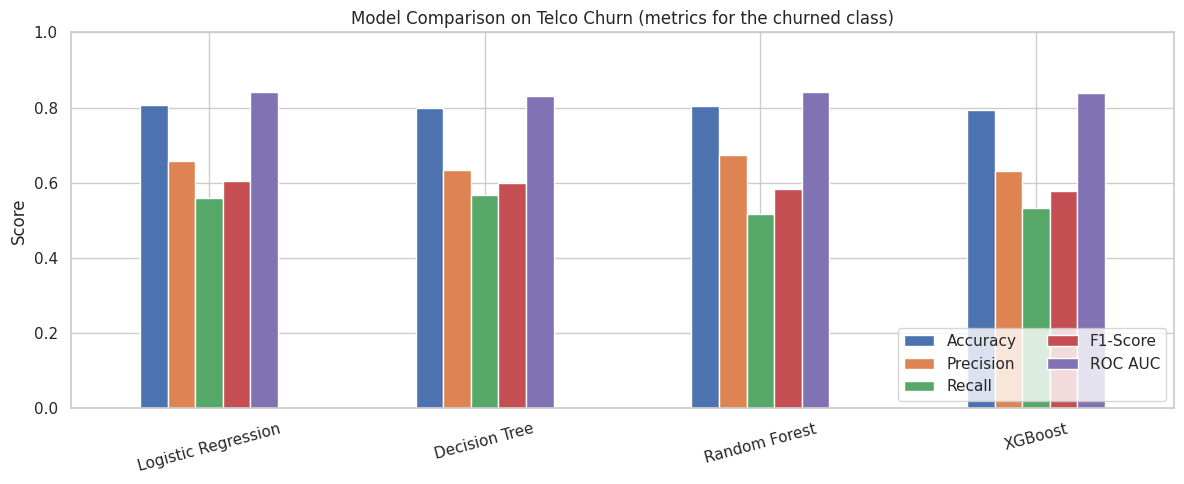

In [11]:
results.plot(kind='bar', figsize=(12, 5), rot=15)

plt.ylabel('Score')
plt.title('Model Comparison on Telco Churn (metrics for the churned class)')
plt.ylim(0, 1)
plt.legend(loc='lower right', ncol=2)
plt.tight_layout()
plt.show()

### ROC curves

Each curve shows the tradeoff between catching churners and raising false alarms as the decision threshold moves. A curve pushed further toward the top left is better, and the area beneath it is the ROC AUC from the table above.

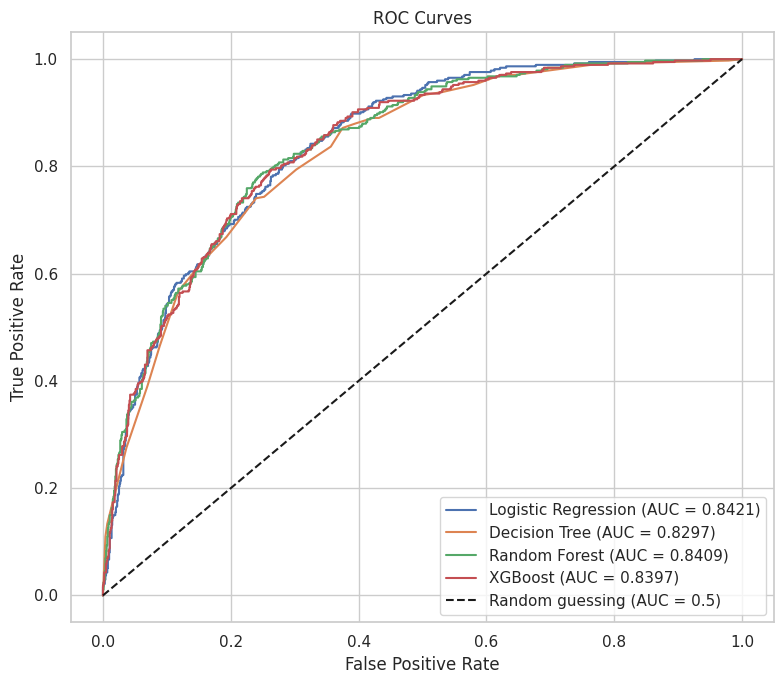

In [12]:
plt.figure(figsize=(8, 7))

for name, proba in [
    ('Logistic Regression', logreg_proba),
    ('Decision Tree', tree_proba),
    ('Random Forest', rf_proba),
    ('XGBoost', xgb_proba)
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random guessing (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Cross-validated check

A single test split of about 1,400 customers is still noisy. Cross-validation gives a more reliable read on whether the ensembles genuinely beat the baselines.

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, model in [
    ('Logistic Regression', logreg),
    ('Decision Tree', tree),
    ('Random Forest', rf),
    ('XGBoost', xgb)
]:
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = {'CV Mean ROC AUC': scores.mean(), 'CV Std Dev': scores.std()}

cv_df = pd.DataFrame(cv_results).T
print(cv_df.round(4).to_string())

                     CV Mean ROC AUC  CV Std Dev
Logistic Regression           0.8451      0.0134
Decision Tree                 0.8300      0.0105
Random Forest                 0.8456      0.0123
XGBoost                       0.8384      0.0099


## 7. Feature Importances

Both ensembles can report which features they leaned on most. The feature names have to be pulled out of the fitted `ColumnTransformer`, because `OneHotEncoder` expands each categorical column into several binary columns.

In [14]:
feature_names = rf.named_steps['preprocessor'].get_feature_names_out()

rf_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.named_steps['classifier'].feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

xgb_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb.named_steps['classifier'].feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Total features after encoding:", len(feature_names))
print()
print("RANDOM FOREST, TOP 10")
print(rf_importance.head(10).to_string(index=False))
print()
print("XGBOOST, TOP 10")
print(xgb_importance.head(10).to_string(index=False))

Total features after encoding: 45

RANDOM FOREST, TOP 10
                                    Feature  Importance
                          numerical__tenure    0.145370
                    numerical__TotalCharges    0.115290
       categorical__Contract_Month-to-month    0.110552
                  numerical__MonthlyCharges    0.076473
             categorical__OnlineSecurity_No    0.063724
   categorical__InternetService_Fiber optic    0.051514
                categorical__TechSupport_No    0.049437
categorical__PaymentMethod_Electronic check    0.044152
             categorical__Contract_Two year    0.036383
           categorical__InternetService_DSL    0.022462

XGBOOST, TOP 10
                                    Feature  Importance
       categorical__Contract_Month-to-month    0.246397
   categorical__InternetService_Fiber optic    0.132788
             categorical__OnlineSecurity_No    0.103950
                categorical__TechSupport_No    0.044107
             categorical__Cont

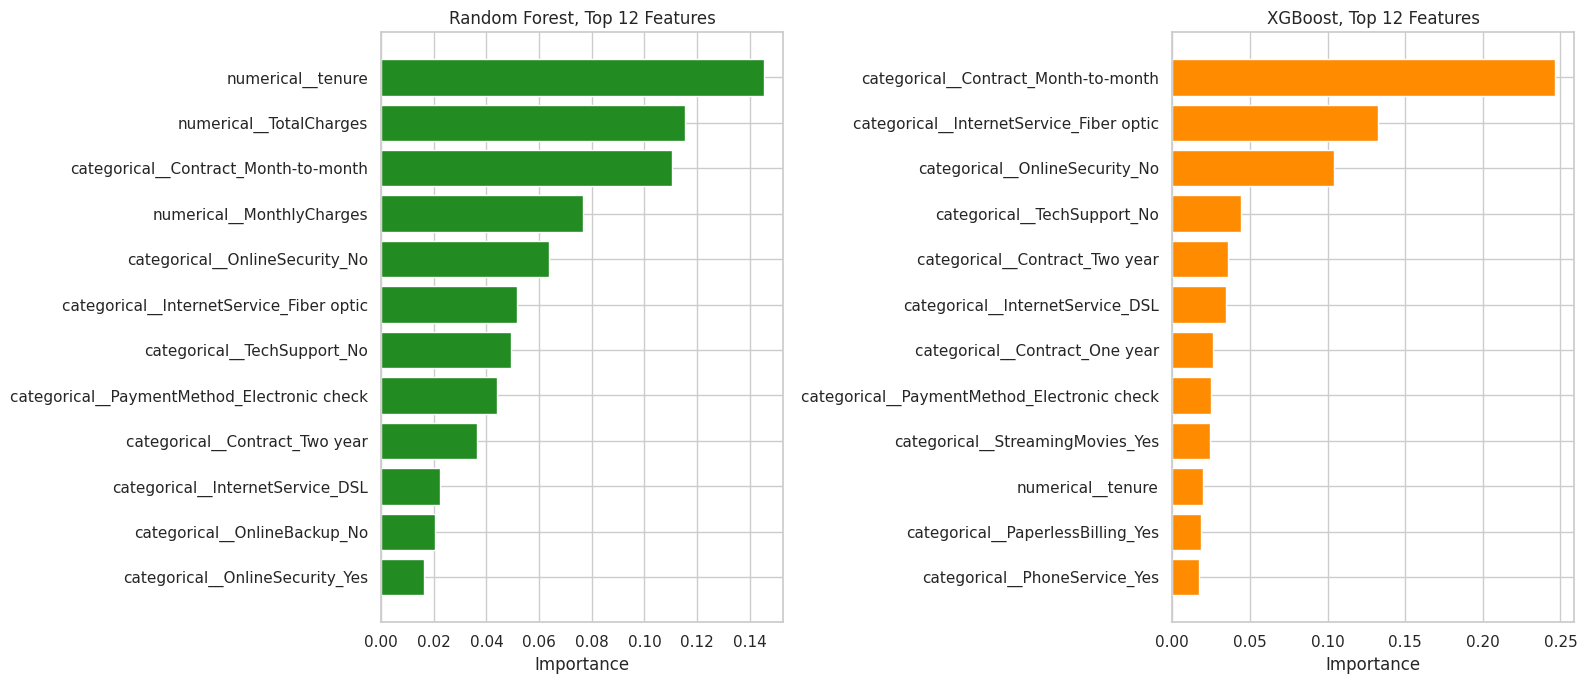

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

rf_top = rf_importance.head(12).iloc[::-1]
axes[0].barh(rf_top['Feature'], rf_top['Importance'], color='forestgreen')
axes[0].set_title('Random Forest, Top 12 Features')
axes[0].set_xlabel('Importance')

xgb_top = xgb_importance.head(12).iloc[::-1]
axes[1].barh(xgb_top['Feature'], xgb_top['Importance'], color='darkorange')
axes[1].set_title('XGBoost, Top 12 Features')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

### Where the two models agree and disagree

Ranking the same features by both models side by side shows how differently they distribute credit.

In [16]:
merged = rf_importance.merge(
    xgb_importance, on='Feature', suffixes=('_RF', '_XGB')
)

merged['Rank_RF'] = merged['Importance_RF'].rank(ascending=False).astype(int)
merged['Rank_XGB'] = merged['Importance_XGB'].rank(ascending=False).astype(int)
merged['Rank_Difference'] = (merged['Rank_RF'] - merged['Rank_XGB']).abs()

top_combined = merged.sort_values('Importance_RF', ascending=False).head(12)

print(top_combined[[
    'Feature', 'Importance_RF', 'Importance_XGB', 'Rank_RF', 'Rank_XGB', 'Rank_Difference'
]].round(4).to_string(index=False))

                                    Feature  Importance_RF  Importance_XGB  Rank_RF  Rank_XGB  Rank_Difference
                          numerical__tenure         0.1454          0.0198        1        10                9
                    numerical__TotalCharges         0.1153          0.0118        2        18               16
       categorical__Contract_Month-to-month         0.1106          0.2464        3         1                2
                  numerical__MonthlyCharges         0.0765          0.0102        4        24               20
             categorical__OnlineSecurity_No         0.0637          0.1039        5         3                2
   categorical__InternetService_Fiber optic         0.0515          0.1328        6         2                4
                categorical__TechSupport_No         0.0494          0.0441        7         4                3
categorical__PaymentMethod_Electronic check         0.0442          0.0251        8         8                0
 

In [17]:
rf_top10 = set(rf_importance.head(10)['Feature'])
xgb_top10 = set(xgb_importance.head(10)['Feature'])

shared = rf_top10 & xgb_top10

print("Features in both top 10 lists:", len(shared), "out of 10")
print()
for f in sorted(shared):
    print("  ", f)

print()
print("Only in Random Forest top 10:")
for f in sorted(rf_top10 - xgb_top10):
    print("  ", f)

print()
print("Only in XGBoost top 10:")
for f in sorted(xgb_top10 - rf_top10):
    print("  ", f)

Features in both top 10 lists: 8 out of 10

   categorical__Contract_Month-to-month
   categorical__Contract_Two year
   categorical__InternetService_DSL
   categorical__InternetService_Fiber optic
   categorical__OnlineSecurity_No
   categorical__PaymentMethod_Electronic check
   categorical__TechSupport_No
   numerical__tenure

Only in Random Forest top 10:
   numerical__MonthlyCharges
   numerical__TotalCharges

Only in XGBoost top 10:
   categorical__Contract_One year
   categorical__StreamingMovies_Yes


### Why the importance scores look so different

The two models measure importance in related but not identical ways, and more importantly they build trees under different constraints.

Random Forest spreads credit around. Because each split only sees a random subset of features, a strong predictor is often unavailable when a split is made, so correlated alternatives get used instead and pick up importance of their own. XGBoost concentrates credit. Each tree is built to fix what remains wrong, so once a dominant feature has been exploited, later trees move on to whatever is still unexplained, and the strongest features can end up with a large share of the total.

A practical consequence: neither ranking should be read as a measure of true causal influence. They describe what each model relied on, which is a useful pointer for where the business should investigate, not proof of what drives churn.

## 8. How Random Forest and XGBoost Differ

Random Forest builds all of its trees **in parallel and independently**, with each tree trained on a random sample of rows and choosing from a random subset of features at every split, and the final prediction is a vote across the whole forest. XGBoost builds its trees **sequentially**, where each new tree is trained specifically on the errors the current ensemble is still making, so the trees are deliberately dependent on one another rather than independent. The practical difference is that Random Forest reduces **variance** by averaging away the instability of individual deep trees, while XGBoost reduces **bias** by having many shallow trees chip away at the remaining error step by step. This also explains their different personalities in use: Random Forest is hard to break and works well with default settings, whereas XGBoost usually reaches a higher ceiling but is more sensitive to its learning rate and tree depth, and can overfit if left to run too long.

## 9. Handling Class Imbalance in the Ensembles

Section 3 of Task 6 flagged the roughly 73 to 27 imbalance. Both ensembles have a built in way to address it.

- **Random Forest** takes `class_weight='balanced'`, which weights each class inversely to how often it appears.
- **XGBoost** takes `scale_pos_weight`, set to the ratio of negative to positive cases, which scales the gradient contribution of the minority class.

The versions below show what changes when the imbalance is accounted for.

In [18]:
# Ratio of non-churners to churners in the training data
scale_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight ratio:", round(scale_ratio, 4))

rf_balanced = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=5,
        class_weight='balanced', random_state=42, n_jobs=-1
    ))
])
rf_balanced.fit(X_train, y_train)
rf_bal_pred = rf_balanced.predict(X_test)
rf_bal_proba = rf_balanced.predict_proba(X_test)[:, 1]

xgb_balanced = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_ratio,
        random_state=42, eval_metric='logloss', n_jobs=-1
    ))
])
xgb_balanced.fit(X_train, y_train)
xgb_bal_pred = xgb_balanced.predict(X_test)
xgb_bal_proba = xgb_balanced.predict_proba(X_test)[:, 1]

print("Balanced versions trained.")

scale_pos_weight ratio: 2.7686
Balanced versions trained.


In [19]:
balanced_results = pd.DataFrame({
    'Random Forest': get_metrics(y_test, rf_pred, rf_proba),
    'Random Forest (balanced)': get_metrics(y_test, rf_bal_pred, rf_bal_proba),
    'XGBoost': get_metrics(y_test, xgb_pred, xgb_proba),
    'XGBoost (balanced)': get_metrics(y_test, xgb_bal_pred, xgb_bal_proba)
}).T

print(balanced_results.round(4).to_string())

                          Accuracy  Precision  Recall  F1-Score  ROC AUC
Random Forest               0.8048     0.6725  0.5160    0.5840   0.8409
Random Forest (balanced)    0.7644     0.5407  0.7460    0.6270   0.8413
XGBoost                     0.7935     0.6317  0.5321    0.5776   0.8397
XGBoost (balanced)          0.7601     0.5336  0.7647    0.6286   0.8365


Note what stays almost unchanged: **ROC AUC**. That is expected, because balancing shifts where the model draws its decision line, not how well it ranks customers by risk. Accuracy and recall move a lot, while the model's underlying ability to separate churners from non churners is barely affected.

This is a useful thing to understand. If a retention team plans to contact the top 500 highest risk customers, ranking quality is what matters, and rebalancing changes very little. If the model's raw yes or no label drives an automated action, then the threshold, and therefore the balancing, matters a great deal.

## 10. Final Comparison Table

All models in one table, ready to copy into the README.

In [20]:
final_table = pd.DataFrame({
    'Logistic Regression (Task 6)': get_metrics(y_test, logreg_pred, logreg_proba),
    'Decision Tree (Task 6)': get_metrics(y_test, tree_pred, tree_proba),
    'Random Forest': get_metrics(y_test, rf_pred, rf_proba),
    'XGBoost': get_metrics(y_test, xgb_pred, xgb_proba),
    'Random Forest (balanced)': get_metrics(y_test, rf_bal_pred, rf_bal_proba),
    'XGBoost (balanced)': get_metrics(y_test, xgb_bal_pred, xgb_bal_proba)
}).T.round(4)

print(final_table.to_string())

                              Accuracy  Precision  Recall  F1-Score  ROC AUC
Logistic Regression (Task 6)    0.8055     0.6572  0.5588    0.6040   0.8421
Decision Tree (Task 6)          0.7984     0.6347  0.5668    0.5989   0.8297
Random Forest                   0.8048     0.6725  0.5160    0.5840   0.8409
XGBoost                         0.7935     0.6317  0.5321    0.5776   0.8397
Random Forest (balanced)        0.7644     0.5407  0.7460    0.6270   0.8413
XGBoost (balanced)              0.7601     0.5336  0.7647    0.6286   0.8365


In [21]:
# Same table as Markdown, ready to paste into the README
print("| Model | Accuracy | Precision | Recall | F1-Score | ROC AUC |")
print("|---|---|---|---|---|---|")
for name, row in final_table.iterrows():
    print(f"| {name} | {row['Accuracy']:.4f} | {row['Precision']:.4f} | "
          f"{row['Recall']:.4f} | {row['F1-Score']:.4f} | {row['ROC AUC']:.4f} |")

| Model | Accuracy | Precision | Recall | F1-Score | ROC AUC |
|---|---|---|---|---|---|
| Logistic Regression (Task 6) | 0.8055 | 0.6572 | 0.5588 | 0.6040 | 0.8421 |
| Decision Tree (Task 6) | 0.7984 | 0.6347 | 0.5668 | 0.5989 | 0.8297 |
| Random Forest | 0.8048 | 0.6725 | 0.5160 | 0.5840 | 0.8409 |
| XGBoost | 0.7935 | 0.6317 | 0.5321 | 0.5776 | 0.8397 |
| Random Forest (balanced) | 0.7644 | 0.5407 | 0.7460 | 0.6270 | 0.8413 |
| XGBoost (balanced) | 0.7601 | 0.5336 | 0.7647 | 0.6286 | 0.8365 |


In [22]:
print("Top 3 features, Random Forest:")
for i, row in rf_importance.head(3).iterrows():
    print(f"  {i + 1}. {row['Feature']} ({row['Importance']:.4f})")

print()
print("Top 3 features, XGBoost:")
for i, row in xgb_importance.head(3).iterrows():
    print(f"  {i + 1}. {row['Feature']} ({row['Importance']:.4f})")

Top 3 features, Random Forest:
  1. numerical__tenure (0.1454)
  2. numerical__TotalCharges (0.1153)
  3. categorical__Contract_Month-to-month (0.1106)

Top 3 features, XGBoost:
  1. categorical__Contract_Month-to-month (0.2464)
  2. categorical__InternetService_Fiber optic (0.1328)
  3. categorical__OnlineSecurity_No (0.1039)


## 11. Summary

**What was built**

1. Random Forest and XGBoost classifiers, both wrapped in the same preprocessing pipeline used in earlier tasks.
2. A comparison against the Logistic Regression and Decision Tree baselines from Task 6, on five metrics including ROC AUC.
3. Feature importance plots for both ensembles, plus a rank comparison showing where they agree.
4. Class weighted versions of both ensembles, showing the effect on recall and the lack of effect on ROC AUC.

**What to take away**

- Ensembles clearly beat the single Decision Tree. Averaging or correcting across many trees removes most of the instability that one tree suffers from.
- Ensembles did **not** beat Logistic Regression here, which is the more useful lesson. Compare the cross validated ROC AUC scores and their standard deviations: the top few models sit within noise of one another. Churn in this dataset has a lot of near linear structure, and a well specified linear model captures it about as well as a forest does.
- This is worth stating plainly rather than glossing over. Ensembles are powerful defaults, not automatic winners, and reaching for the most complex model available is not the same as doing good modelling. A simpler model that matches on accuracy is usually the better choice in production, since it trains faster, is easier to explain to stakeholders, and has fewer ways to fail quietly.
- Random Forest and XGBoost disagree noticeably about which features matter, despite scoring similarly, which is a reminder that importance describes the model rather than reality.

**Limitations**

- Hyperparameters were set to sensible values rather than tuned. Applying `GridSearchCV` or `RandomizedSearchCV` from Task 5 would likely improve both ensembles, XGBoost more than Random Forest, since it is more sensitive to its settings.
- Only the default 0.5 decision threshold was used for the labelled predictions. Choosing a threshold based on the cost of a lost customer versus the cost of a retention offer would be the next practical step.
- No feature engineering was applied here, unlike Task 7. Features such as tenure bands or a count of subscribed services might help.